## Train and test Linear Regression model

Uses a simple linear regression models, and then experiment with both lasso and ridge regularization

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.metrics import mean_squared_error, r2_score, mean_squared_log_error
from sklearn.preprocessing import StandardScaler

In [8]:
df = pd.read_csv('data/engineered_features_scaled.csv')

In [9]:
X = df.drop(columns='revenue')
y = df['revenue']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=1
)

In [19]:
model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_pred_original = np.expm1(y_pred)
y_test_original = np.expm1(y_test)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
rmsle = np.sqrt(mean_squared_log_error(y_test_original, y_pred_original))

print("RMSLE:", rmsle)
print("MSE:", mse)
print("R2:", r2)

mse = mean_squared_error(y_test_original, y_pred_original)
r2 = r2_score(y_test_original, y_pred_original)

print("ME (original scale):", np.sqrt(mse))
print("R2 (original scale):", r2)

RMSLE: 2.1467684037700945
MSE: 4.6086145794256
R2: 0.4275727204764832
ME (original scale): 125830012.34096032
R2 (original scale): 0.14362565807240746


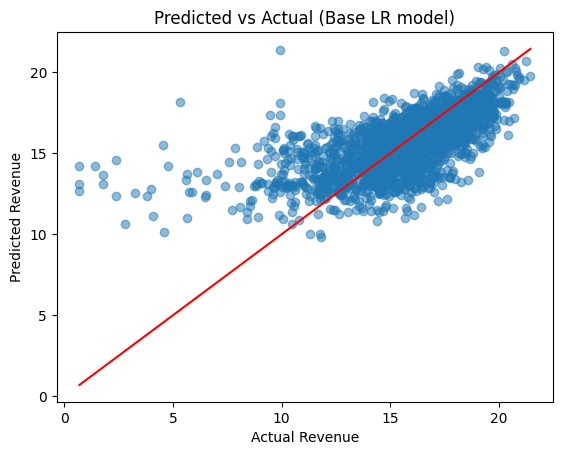

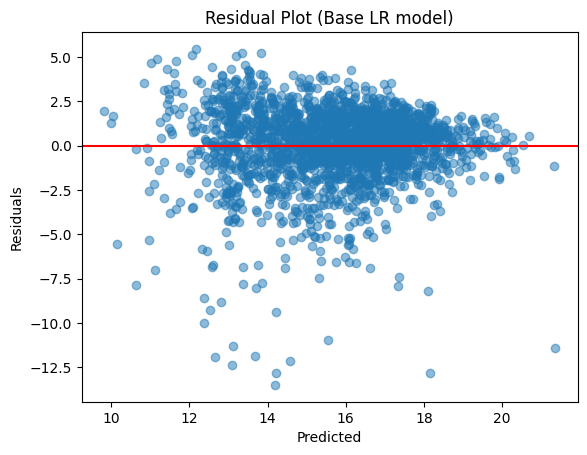

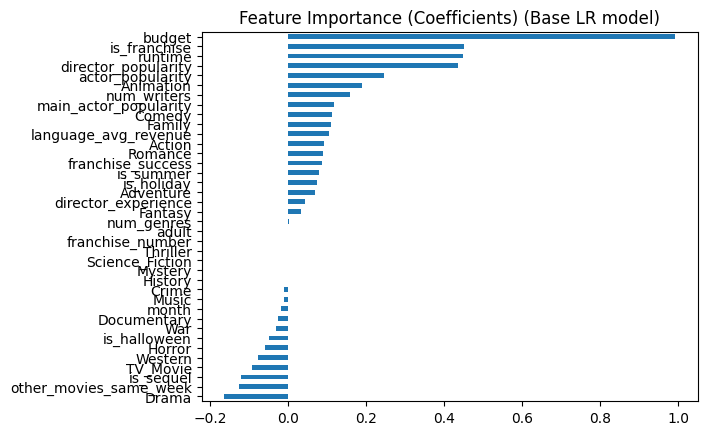

In [30]:
## Show graphs to evalaute model


## Actual vs predicted
plt.scatter(y_test, y_pred, alpha=0.5)
plt.xlabel("Actual Revenue")
plt.ylabel("Predicted Revenue")
plt.title("Predicted vs Actual (Base LR model)")

plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='red')

plt.show()


## Residuals graph
residuals = y_test - y_pred

plt.scatter(y_pred, residuals, alpha=0.5)
plt.axhline(0, color='red')
plt.xlabel("Predicted")
plt.ylabel("Residuals")
plt.title("Residual Plot (Base LR model)")
plt.show()

## Feature coefficients
coeffs = pd.Series(model.coef_, index=X_train.columns)

coeffs.sort_values().plot(kind='barh')
plt.title("Feature Importance (Coefficients) (Base LR model)")
plt.show()

In [13]:
## Scale data for regularization

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [18]:
alphas = [0.001, 0.01, 0.5]

for a in alphas:
  print("With alpha: ", a)
  model = Lasso(alpha=a)
  model.fit(X_train_scaled, y_train)

  y_pred = model.predict(X_test_scaled)

  mse = mean_squared_error(y_test, y_pred)
  r2 = r2_score(y_test, y_pred)
  print(" MSE:", mse)
  print(" R2:", r2)

  y_pred_original = np.expm1(y_pred)
  y_test_original = np.expm1(y_test)

  mse = mean_squared_error(y_test_original, y_pred_original)
  r2 = r2_score(y_test_original, y_pred_original)
  rmsle = np.sqrt(mean_squared_log_error(y_test_original, y_pred_original))

  print(" RMSLE:", rmsle)
  print(" ME (original scale):", np.sqrt(mse))
  print(" R2 (original scale):", r2)

With alpha:  0.001
 MSE: 4.607871010672729
 R2: 0.42766507774155915
 RMSLE: 2.146595213512023
 ME (original scale): 124919275.3933596
 R2 (original scale): 0.15597738928168958
With alpha:  0.01
 MSE: 4.6051103324349105
 R2: 0.42800797635155985
 RMSLE: 2.145952080647401
 ME (original scale): 119707882.81523272
 R2 (original scale): 0.2249304627272558
With alpha:  0.5
 MSE: 5.771801298785507
 R2: 0.28309550332892486
 RMSLE: 2.40245734588265
 ME (original scale): 140414675.227703
 R2 (original scale): -0.06640007757483124


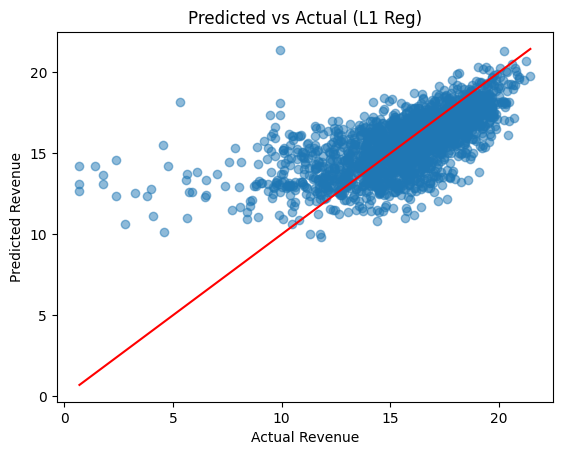

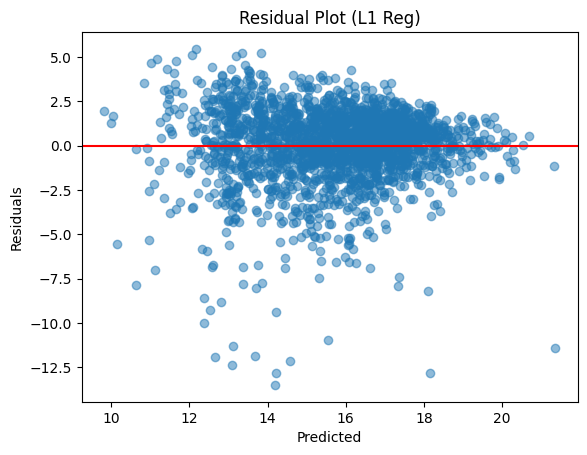

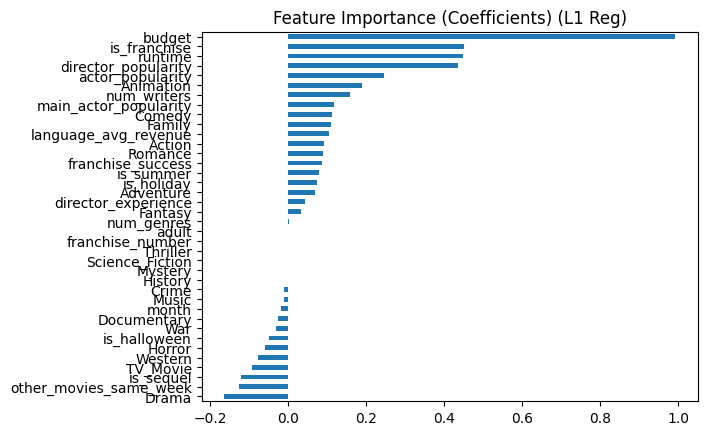

In [31]:
## Alpha = 0.01 best performance, evaluate
model = Lasso(alpha=0.01)
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)


## Actual vs predicted
plt.scatter(y_test, y_pred, alpha=0.5)
plt.xlabel("Actual Revenue")
plt.ylabel("Predicted Revenue")
plt.title("Predicted vs Actual (L1 Reg)")

plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='red')

plt.show()


## Residuals graph
residuals = y_test - y_pred

plt.scatter(y_pred, residuals, alpha=0.5)
plt.axhline(0, color='red')
plt.xlabel("Predicted")
plt.ylabel("Residuals")
plt.title("Residual Plot (L1 Reg)")
plt.show()

## Feature coefficients
coeffs = pd.Series(model.coef_, index=X_train.columns)

coeffs.sort_values().plot(kind='barh')
plt.title("Feature Importance (Coefficients) (L1 Reg)")
plt.show()

In [17]:
alphas = [0.01, 0.1, 0.5, 1.0]

for a in alphas:
  print("With alpha: ", a)
  model = Ridge(alpha=a)
  model.fit(X_train_scaled, y_train)

  y_pred = model.predict(X_test_scaled)

  mse = mean_squared_error(y_test, y_pred)
  r2 = r2_score(y_test, y_pred)
  print(" MSE:", mse)
  print(" R2:", r2)

  y_pred_original = np.expm1(y_pred)
  y_test_original = np.expm1(y_test)

  mse = mean_squared_error(y_test_original, y_pred_original)
  r2 = r2_score(y_test_original, y_pred_original)
  rmsle = np.sqrt(mean_squared_log_error(y_test_original, y_pred_original))

  print(" RMSLE:", rmsle)
  print(" ME (original scale):", np.sqrt(mse))
  print(" R2 (original scale):", r2)

With alpha:  0.01
 MSE: 4.6086142752088755
 R2: 0.42757275826266583
 RMSLE: 2.146768332915519
 ME (original scale): 125829737.24770473
 R2 (original scale): 0.14362940252961331
With alpha:  0.1
 MSE: 4.608611537598401
 R2: 0.4275730982960727
 RMSLE: 2.14676769530343
 ME (original scale): 125827261.7072484
 R2 (original scale): 0.1436630982084257
With alpha:  0.5
 MSE: 4.608599377843765
 R2: 0.4275746086361426
 RMSLE: 2.1467648631938627
 ME (original scale): 125816265.81207101
 R2 (original scale): 0.14381276020132006
With alpha:  1.0
 MSE: 4.608584195139747
 R2: 0.4275764944510241
 RMSLE: 2.146761327008605
 ME (original scale): 125802535.8704646
 R2 (original scale): 0.14399961615854262


In [ ]:
## No change across different alphas, ridge regularization doesn't apply very well to our dataset